In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

In [3]:
DATA_PATH = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0534/data/clean_news_dataset.csv"

MODEL_DIR = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0534/models"
RESULTS_DIR = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0534/results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (39105, 8)
['title', 'text', 'subject', 'date', 'label', 'content', 'text_length', 'clean_text']


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate content:", df["content"].duplicated().sum())

Missing values:
title          0
text           0
subject        0
date           0
label          0
content        0
text_length    0
clean_text     5
dtype: int64
Duplicate rows: 0
Duplicate content: 0


In [6]:
df["clean_text"] = df["clean_text"].fillna("")

print("Missing clean_text values:", df["clean_text"].isnull().sum())

Missing clean_text values: 0


In [7]:
X = df["clean_text"]
y = df["label"]

print("Features:", X.shape)
print("Target:", y.shape)
print("Classes:", sorted(y.unique()))

Features: (39105,)
Target: (39105,)
Classes: [np.int64(0), np.int64(1)]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31284
Testing samples: 7821


In [9]:
MAX_WORDS = 20000
MAX_LEN = 500

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 174140


In [10]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Training sequences:", len(X_train_seq))
print("Testing sequences:", len(X_test_seq))

Training sequences: 31284
Testing sequences: 7821


In [11]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training padded shape:", X_train_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

Training padded shape: (31284, 500)
Testing padded shape: (7821, 500)


In [12]:
gru_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    ),
    GRU(64),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 355s 800ms/step - accuracy: 0.5484 - loss: 0.6737 - val_accuracy: 0.7226 - val_loss: 0.4934
Epoch 2/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 340s 772ms/step - accuracy: 0.9481 - loss: 0.1285 - val_accuracy: 0.9926 - val_loss: 0.0284
Epoch 3/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 340s 772ms/step - accuracy: 0.9959 - loss: 0.0193 - val_accuracy: 0.9952 - val_loss: 0.0169
Epoch 4/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 339s 772ms/step - accuracy: 0.9984 - loss: 0.0098 - val_accuracy: 0.9978 - val_loss: 0.0115
Epoch 5/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 385s 778ms/step - accuracy: 0.9941 - loss: 0.0265 - val_accuracy: 0.9939 - val_loss: 0.0265
Epoch 6/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 342s 776ms/step - accuracy: 0.9982 - loss: 0.0101 - val_accuracy: 0.9952 - val_loss: 0.0181


In [14]:
test_loss, test_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", round(test_accuracy * 100, 2))

Test Loss: 0.01486812811344862
Test Accuracy: 0.997187077999115
Test Accuracy (%): 99.72


In [15]:
y_prob = gru_model.predict(
    X_test_pad,
    verbose=0
).ravel()

y_pred = (y_prob >= 0.5).astype(int)

print("Predictions generated:", len(y_pred))

Predictions generated: 7821


In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9971870604781997
Precision: 0.9960009409550694
Recall: 0.9988204765274828
F1 Score: 0.9974087161366313


In [17]:
print("Accuracy (%):", round(accuracy * 100, 2))
print("Precision (%):", round(precision * 100, 2))
print("Recall (%):", round(recall * 100, 2))
print("F1 Score (%):", round(f1 * 100, 2))

Accuracy (%): 99.72
Precision (%): 99.6
Recall (%): 99.88
F1 Score (%): 99.74


In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3565   17]
 [   5 4234]]


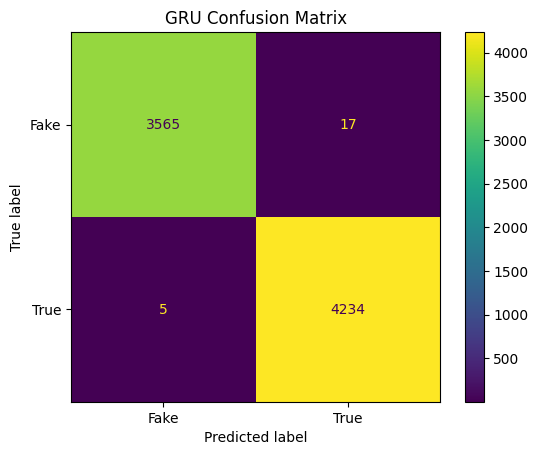

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)

disp.plot()
plt.title("GRU Confusion Matrix")
plt.show()

In [20]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "True"]
))

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3582
        True       1.00      1.00      1.00      4239

    accuracy                           1.00      7821
   macro avg       1.00      1.00      1.00      7821
weighted avg       1.00      1.00      1.00      7821



In [21]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
print("ROC-AUC (%):", round(roc_auc * 100, 2))

ROC-AUC: 0.999588220518598
ROC-AUC (%): 99.96


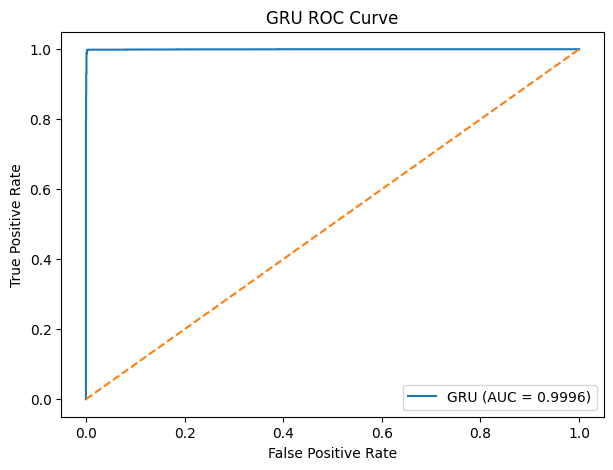

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"GRU (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GRU ROC Curve")
plt.legend()
plt.show()

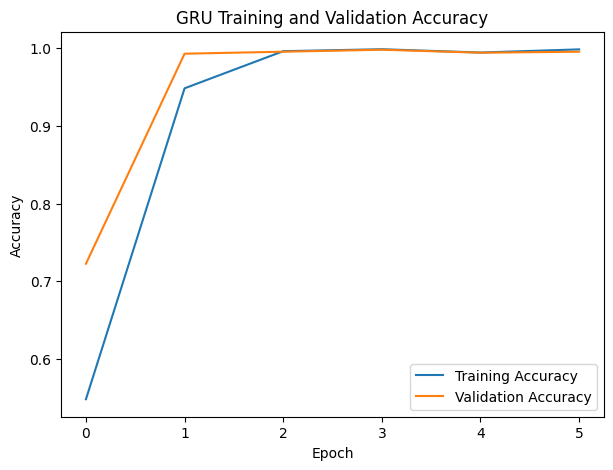

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training and Validation Accuracy")
plt.legend()
plt.show()

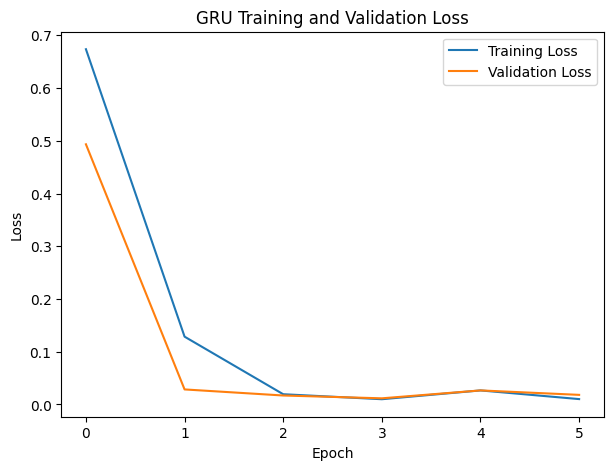

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.show()

In [25]:
MODEL_PATH = os.path.join(MODEL_DIR, "gru_model.keras")
TOKENIZER_PATH = os.path.join(MODEL_DIR, "gru_tokenizer.pkl")

gru_model.save(MODEL_PATH)

with open(TOKENIZER_PATH, "wb") as f:
    pickle.dump(tokenizer, f)

print("GRU model saved successfully!")
print("Tokenizer saved successfully!")

GRU model saved successfully!
Tokenizer saved successfully!


In [26]:
results = pd.DataFrame({
    "Model": ["GRU"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "ROC_AUC": [roc_auc]
})

RESULTS_PATH = os.path.join(RESULTS_DIR, "gru_results.csv")

results.to_csv(
    RESULTS_PATH,
    index=False
)

display(results)
print("Results saved successfully!")

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,GRU,0.997187,0.996001,0.99882,0.997409,0.999588


Results saved successfully!


In [27]:
loaded_model = load_model(MODEL_PATH)

with open(TOKENIZER_PATH, "rb") as f:
    loaded_tokenizer = pickle.load(f)

sample_text = X_test.iloc[0]

sample_sequence = loaded_tokenizer.texts_to_sequences([sample_text])

sample_padding = pad_sequences(
    sample_sequence,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

sample_probability = loaded_model.predict(
    sample_padding,
    verbose=0
)[0][0]

sample_prediction = int(sample_probability >= 0.5)

print("Actual Label:", y_test.iloc[0])
print("Predicted Label:", sample_prediction)
print("Prediction Probability:", sample_probability)
print("Model verification successful!")

Actual Label: 0
Predicted Label: 0
Prediction Probability: 0.00055975065
Model verification successful!


In [28]:
print("Final Dataset Shape:", df.shape)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Vocabulary Size:", len(tokenizer.word_index))
print("Maximum Sequence Length:", MAX_LEN)
print("Accuracy:", round(accuracy * 100, 2))
print("Precision:", round(precision * 100, 2))
print("Recall:", round(recall * 100, 2))
print("F1 Score:", round(f1 * 100, 2))
print("ROC-AUC:", round(roc_auc * 100, 2))
print("Model Path:", MODEL_PATH)
print("Tokenizer Path:", TOKENIZER_PATH)
print("Results Path:", RESULTS_PATH)

Final Dataset Shape: (39105, 8)
Training Samples: 31284
Testing Samples: 7821
Vocabulary Size: 174140
Maximum Sequence Length: 500
Accuracy: 99.72
Precision: 99.6
Recall: 99.88
F1 Score: 99.74
ROC-AUC: 99.96
Model Path: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0534/models/gru_model.keras
Tokenizer Path: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0534/models/gru_tokenizer.pkl
Results Path: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0534/results/gru_results.csv
